# Atividade 6 — Análise Fatorial Desbalanceada: Resistência à Compressão do Concreto

## Enunciado

---

Faça uma análise completa da base de dados apresentada pelo seu grupo, considerando um experimento com **três fatores** e **tamanhos amostrais desiguais** entre as combinações de tratamentos. A análise deverá ser conduzida utilizando a **abordagem de regressão para modelos fatoriais desbalanceados**.

O relatório deve incluir:
- Descrição da estrutura do experimento
- Formulação do modelo completo
- Definição das variáveis indicadoras utilizadas
- Testes dos efeitos fatoriais por comparação entre modelos reduzidos e completos
- Escolha de um modelo final hierarquicamente consistente
- Análise de resíduos
- Interpretação estatística dos resultados
- Comparações múltiplas quando pertinente

---

## Base de Dados

A base utilizada é o **Concrete Compressive Strength Data Set** (UCI Machine Learning Repository). A variável resposta é a **resistência à compressão do concreto** (MPa). Os três fatores de interesse são definidos a partir da presença ou ausência dos seguintes ingredientes:

| Fator | Símbolo | Nível 0 | Nível 1 |
|-------|---------|---------|----------|
| Escória de alto-forno | `Es` | Ausente | Presente |
| Cinza Volante | `CinV` | Ausente | Presente |
| Superplastificante | `SupP` | Ausente | Presente |

Como os ingredientes aparecem em proporções contínuas no banco original, binarizamos: **presente** se a quantidade for maior que zero, **ausente** caso contrário. O resultado é um experimento **fatorial $2^3$ desbalanceado** — há replicação em todas as $2^3 = 8$ combinações, mas o número de observações por célula varia consideravelmente.

---

## 1. Preparação dos Dados

In [67]:
library(readxl)
dados_brutos <- read_excel("Concrete_Data.xls")
colnames(dados_brutos) <- c("Cimento","Escoria","CinzaVolante","Agua",
                            "Superplastificante","AgregadoGraudo",
                            "AgregadoMiudo","Idade","Resistencia")

# Binarização: 1 = ingrediente presente, 0 = ausente
dados_brutos$Es   <- ifelse(dados_brutos$Escoria > 0, 1, 0)
dados_brutos$CinV <- ifelse(dados_brutos$CinzaVolante > 0, 1, 0)
dados_brutos$SupP <- ifelse(dados_brutos$Superplastificante > 0, 1, 0)

dados <- dados_brutos[, c("Es", "CinV", "SupP", "Resistencia")]

# Converter fatores
dados$Es   <- factor(dados$Es,   levels = c(0, 1), labels = c("Aus", "Pre"))
dados$CinV <- factor(dados$CinV, levels = c(0, 1), labels = c("Aus", "Pre"))
dados$SupP <- factor(dados$SupP, levels = c(0, 1), labels = c("Aus", "Pre"))

cat("Dimensões do banco de dados:", nrow(dados), "obs. x", ncol(dados), "variáveis\n")
head(dados)

Dimensões do banco de dados: 1030 obs. x 4 variáveis


Es,CinV,SupP,Resistencia
<fct>,<fct>,<fct>,<dbl>
Aus,Aus,Pre,79.98611
Aus,Aus,Pre,61.88737
Pre,Aus,Aus,40.26954
Pre,Aus,Aus,41.05278
Pre,Aus,Aus,44.29608
Pre,Aus,Aus,47.02985


### 1.1 Distribuição amostral por combinação de tratamentos

O primeiro passo é verificar quantas observações existem em cada uma das 8 células do arranjo fatorial. O desbalanceamento é um fato central desta análise — ele impede o uso direto da ANOVA clássica e motiva a abordagem de regressão.

In [68]:
# Contagem de observações por combinação de tratamentos
tab_n <- xtabs(~ Es + CinV + SupP, data = dados)
print(tab_n)
cat("\nTotal de observações:", sum(tab_n), "\n")
cat("Mínimo por célula:", min(tab_n), "| Máximo:", max(tab_n), "\n")

, , SupP = Aus

     CinV
Es    Aus Pre
  Aus 209   1
  Pre 164   5

, , SupP = Pre

     CinV
Es    Aus Pre
  Aus  23 233
  Pre 170 225


Total de observações: 1030 
Mínimo por célula: 1 | Máximo: 233 


---

## 2. Estrutura Experimental e Modelo

### 2.1 Estrutura do experimento

Trata-se de um experimento **fatorial $2^3$ completamente aleatorizado com tamanhos amostrais desiguais**, em que:

- **Fator A** = Escória (`Es`): Ausente / Presente -> $a = 2$ níveis  
- **Fator B** = Cinza Volante (`CinV`): Ausente / Presente -> $b = 2$ níveis  
- **Fator C** = Superplastificante (`SupP`): Ausente / Presente -> $c = 2$ níveis  
- **Variável resposta**: Resistência à compressão do concreto (MPa)

O modelo fatorial completo com três fatores e todas as interações é:

$$Y_{ijkl} = \mu + \alpha_i + \beta_j + \gamma_k + (\alpha\beta)_{ij} + (\alpha\gamma)_{ik} + (\beta\gamma)_{jk} + (\alpha\beta\gamma)_{ijk} + \varepsilon_{ijkl}$$

onde:
- $Y_{ijkl}$: $l$-ésima observação no nível $i$ de Escória, $j$ de Cinza Volante e $k$ de Superplastificante  
- $\mu$: média geral  
- $\alpha_i$: efeito principal da Escória  
- $\beta_j$: efeito principal da Cinza Volante  
- $\gamma_k$: efeito principal do Superplastificante  
- $(\alpha\beta)_{ij}$, $(\alpha\gamma)_{ik}$, $(\beta\gamma)_{jk}$: interações de dois fatores  
- $(\alpha\beta\gamma)_{ijk}$: interação tripla  
- $\varepsilon_{ijkl} \sim N(0, \sigma^2)$: erro aleatório

### 2.2 Codificação das variáveis indicadoras (*dummies*)

Como cada fator tem 2 níveis, basta **uma** variável indicadora por fator, com a categoria de referência sendo **Ausente** (nível 0). Definimos:

| Variável | Definição |
|----------|----------|
| $X_1$ | 1 se Escória Presente, 0 c.c. |
| $X_2$ | 1 se Cinza Volante Presente, 0 c.c. |
| $X_3$ | 1 se Superplastificante Presente, 0 c.c. |
| $X_1 X_2$ | interação Escória × Cinza Volante |
| $X_1 X_3$ | interação Escória × Superplastificante |
| $X_2 X_3$ | interação Cinza Volante × Superplastificante |
| $X_1 X_2 X_3$ | interação tripla |

O modelo de regressão equivalente ao modelo fatorial completo é então:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_{12} X_1 X_2 + \beta_{13} X_1 X_3 + \beta_{23} X_2 X_3 + \beta_{123} X_1 X_2 X_3 + \varepsilon$$

Este modelo tem **8 parâmetros**, correspondendo exatamente às 8 médias de célula do fatorial $2^3$.

---

## 3. Análise Exploratória

In [69]:
library(dplyr)

# Médias e desvios-padrão por combinação de tratamentos
resumo <- dados %>%
  group_by(Es, CinV, SupP) %>%
  summarise(
    n      = n(),
    Media  = round(mean(Resistencia), 2),
    DP     = round(sd(Resistencia), 2),
    .groups = "drop"
  )

print(resumo)

# A tibble: 8 × 6
  Es    CinV  SupP      n Media    DP
  <fct> <fct> <fct> <int> <dbl> <dbl>
1 Aus   Aus   Aus     209  29.8  14.6
2 Aus   Aus   Pre      23  51.8  14.6
3 Aus   Pre   Aus       1  64.0  NA  
4 Aus   Pre   Pre     233  31.2  13.3
5 Pre   Aus   Aus     164  29.0  14.8
6 Pre   Aus   Pre     170  50.8  17.0
7 Pre   Pre   Aus       5  26.4  10.9
8 Pre   Pre   Pre     225  38.3  14.2


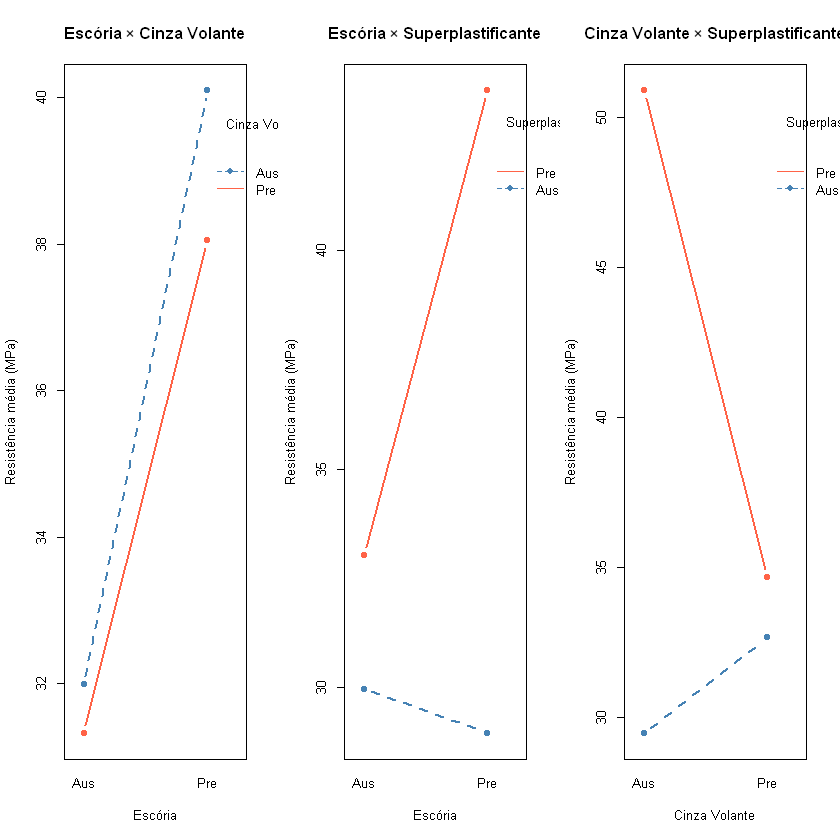

In [70]:
# Gráficos de perfis de médias para visualizar efeitos principais e interações
par(mfrow = c(1, 3))

# Escória × CinzaVolante (marginalizado sobre SupP)
interaction.plot(dados$Es, dados$CinV, dados$Resistencia,
                 type = "b", col = c("steelblue", "tomato"), lwd = 2, pch = 19,
                 xlab = "Escória", ylab = "Resistência média (MPa)",
                 trace.label = "Cinza Volante",
                 main = "Escória × Cinza Volante")

# Escória × SupP
interaction.plot(dados$Es, dados$SupP, dados$Resistencia,
                 type = "b", col = c("steelblue", "tomato"), lwd = 2, pch = 19,
                 xlab = "Escória", ylab = "Resistência média (MPa)",
                 trace.label = "Superplast.",
                 main = "Escória × Superplastificante")

# CinzaVolante × SupP
interaction.plot(dados$CinV, dados$SupP, dados$Resistencia,
                 type = "b", col = c("steelblue", "tomato"), lwd = 2, pch = 19,
                 xlab = "Cinza Volante", ylab = "Resistência média (MPa)",
                 trace.label = "Superplast.",
                 main = "Cinza Volante × Superplastificante")

par(mfrow = c(1, 1))

Os gráficos de perfis de médias permitem uma leitura inicial dos dados:

- Se as linhas forem **paralelas**, o modelo sem interação (aditivo) é adequado;
- Se as linhas se **cruzarem ou divergirem**, há indício de interação entre os fatores.

A avaliação visual será complementada pelos testes formais de hipóteses a seguir, via comparação de modelos aninhados.

---

## 4. Construção das Variáveis Indicadoras e Ajuste do Modelo Completo

In [71]:
# Criação das dummies e termos de interação manualmente
# (referência: Es = Aus, CinV = Aus, SupP = Aus)
dados$X1  <- as.numeric(dados$Es   == "Pre")   # Escória presente
dados$X2  <- as.numeric(dados$CinV == "Pre")   # Cinza Volante presente
dados$X3  <- as.numeric(dados$SupP == "Pre")   # Superplastificante presente

dados$X12  <- dados$X1 * dados$X2              # Interação Es × CinV
dados$X13  <- dados$X1 * dados$X3              # Interação Es × SupP
dados$X23  <- dados$X2 * dados$X3              # Interação CinV × SupP
dados$X123 <- dados$X1 * dados$X2 * dados$X3  # Interação tripla

cat("Variáveis do banco de análise:\n")
print(head(dados))

Variáveis do banco de análise:
# A tibble: 6 × 11
  Es    CinV  SupP  Resistencia    X1    X2    X3   X12   X13   X23  X123
  <fct> <fct> <fct>       <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 Aus   Aus   Pre          80.0     0     0     1     0     0     0     0
2 Aus   Aus   Pre          61.9     0     0     1     0     0     0     0
3 Pre   Aus   Aus          40.3     1     0     0     0     0     0     0
4 Pre   Aus   Aus          41.1     1     0     0     0     0     0     0
5 Pre   Aus   Aus          44.3     1     0     0     0     0     0     0
6 Pre   Aus   Aus          47.0     1     0     0     0     0     0     0


In [72]:
# Ajuste do modelo completo (todos os efeitos principais e interações)
mod_completo <- lm(Resistencia ~ X1 + X2 + X3 + X12 + X13 + X23 + X123,
                   data = dados)

summary(mod_completo)


Call:
lm(formula = Resistencia ~ X1 + X2 + X3 + X12 + X13 + X23 + X123, 
    data = dados)

Residuals:
    Min      1Q  Median      3Q     Max 
-32.476 -11.765  -0.397  10.655  45.182 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  29.8059     1.0162  29.330  < 2e-16 ***
X1           -0.7710     1.5326  -0.503 0.615036    
X2           34.2119    14.7263   2.323 0.020365 *  
X3           22.0308     3.2275   6.826 1.49e-11 ***
X12         -36.8482    16.1662  -2.279 0.022852 *  
X13          -0.3048     3.6059  -0.085 0.932661    
X23         -54.8655    15.0723  -3.640 0.000286 ***
X123         45.0427    16.5495   2.722 0.006605 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 14.69 on 1022 degrees of freedom
Multiple R-squared:  0.2319,	Adjusted R-squared:  0.2266 
F-statistic: 44.08 on 7 and 1022 DF,  p-value: < 2.2e-16


In [73]:
# Ajuste do modelo completo (todos os efeitos principais e interações)
mod_inv <- lm((Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13 + X23 + X123,
                   data = dados)

summary(mod_inv)

mod_completo <- mod_inv


Call:
lm(formula = (Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13 + X23 + 
    X123, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.03697 -0.01482 -0.00586  0.00590  0.37407 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.043763   0.001962  22.303  < 2e-16 ***
X1           0.011021   0.002959   3.724 0.000207 ***
X2          -0.028142   0.028435  -0.990 0.322549    
X3          -0.022677   0.006232  -3.639 0.000288 ***
X12          0.017474   0.031215   0.560 0.575754    
X13         -0.009552   0.006963  -1.372 0.170380    
X23          0.047684   0.029103   1.638 0.101635    
X123        -0.028266   0.031955  -0.885 0.376607    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.02837 on 1022 degrees of freedom
Multiple R-squared:  0.1205,	Adjusted R-squared:  0.1145 
F-statistic:    20 on 7 and 1022 DF,  p-value: < 2.2e-16


### 4.1 Interpretação dos coeficientes do modelo completo

| Coeficiente | Parâmetro | Interpretação |
|------------|-----------|---------------|
| `(Intercept)` | $\beta_0$ | Média de resistência quando **todos os ingredientes estão ausentes** |
| `X1` | $\beta_1$ | Acréscimo médio de resistência ao adicionar Escória (fixando CinV=0, SupP=0) |
| `X2` | $\beta_2$ | Acréscimo médio ao adicionar Cinza Volante (fixando Es=0, SupP=0) |
| `X3` | $\beta_3$ | Acréscimo médio ao adicionar Superplastificante (fixando Es=0, CinV=0) |
| `X12` | $\beta_{12}$ | Correção de interação: quanto o efeito de Es muda quando CinV está presente |
| `X13` | $\beta_{13}$ | Correção de interação: quanto o efeito de Es muda quando SupP está presente |
| `X23` | $\beta_{23}$ | Correção de interação: quanto o efeito de CinV muda quando SupP está presente |
| `X123` | $\beta_{123}$ | Interação tripla: ajuste adicional quando todos os três estão presentes |

---

## 5. Testes de Hipóteses por Comparação de Modelos

### 5.1 Estratégia

Para dados desbalanceados, as **somas de quadrados do Tipo I** (sequenciais) dependem da ordem de entrada dos termos no modelo, o que as torna inadequadas. Usamos a abordagem de **comparação entre modelos aninhados**: para testar um efeito, comparamos o **modelo completo** com um **modelo reduzido** que omite apenas aquele efeito, mantendo todos os outros. Isso equivale às **Somas de Quadrados do Tipo III** (parciais, ou marginais).

Seguimos uma estratégia **hierárquica de cima para baixo** (*backward*):

1. Testar a interação tripla $ABC$
2. Testar as interações duplas $AB$, $AC$, $BC$
3. Testar os efeitos principais $A$, $B$, $C$

Um efeito de ordem inferior **só é removido** se o efeito de ordem superior que o contém também for não significativo.

### 5.2 Abordagem via `car::Anova` (Tipo III)

Uma forma direta de obter os testes marginais é usar a função `Anova()` do pacote `car` com `type = "III"`.

In [74]:
library(car)

cat("── ANOVA Tipo III (efeitos marginais) — modelo completo:\n")
Anova(mod_completo, type = "III")

── ANOVA Tipo III (efeitos marginais) — modelo completo:


,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.4002786015,1,497.4274041,4.262527e-90
X1,0.0111607491,1,13.8694960,2.066646e-04
X2,0.0007882262,1,0.9795310,3.225489e-01
X3,0.0106550993,1,13.2411234,2.875726e-04
X12,0.0002521526,1,0.3133508,5.757539e-01
X13,0.0015146401,1,1.8822477,1.703800e-01
X23,0.0021602327,1,2.6845276,1.016351e-01
X123,0.0006296199,1,0.7824305,3.766069e-01
Residuals,0.8224008717,1022,NA,NA


### 5.3 Teste da interação tripla $Es \times CinV \times SupP$

Testamos:
$$H_0: \beta_{123} = 0 \qquad H_1: \beta_{123} \neq 0$$

Isso equivale a comparar o modelo completo com o modelo que omite o termo $X_1 X_2 X_3$.

In [75]:
# Modelo sem interação tripla
mod_sem_abc <- lm((Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13 + X23,
                  data = dados)

cat("── Teste F: interação tripla Es × CinV × SupP\n")
anova(mod_sem_abc, mod_completo)

── Teste F: interação tripla Es × CinV × SupP


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1023,0.8230305,NA,NA,NA,NA
2,1022,0.8224009,1,0.0006296199,0.7824305,0.3766069


### 5.4 Testes das interações duplas

Com base no resultado anterior, definimos o **modelo de referência atual** (completo ou sem a tripla, conforme o resultado acima) e testamos cada interação dupla.

As hipóteses para cada uma são da forma:
$$H_0: \beta_{ij} = 0 \qquad H_1: \beta_{ij} \neq 0$$

In [76]:
# Modelo de referência: sem a interação tripla
# (ajuste conforme o resultado do teste acima)
mod_ref <- mod_sem_abc

# Teste da interação Es × CinV
mod_sem_12 <- lm((Resistencia)^-1 ~ X1 + X2 + X3 + X13 + X23, data = dados)
cat("── Teste F: interação Es × CinV (X12)\n")
print(anova(mod_sem_12, mod_ref))

cat("\n")

# Teste da interação Es × SupP
mod_sem_13 <- lm((Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X23, data = dados)
cat("── Teste F: interação Es × SupP (X13)\n")
print(anova(mod_sem_13, mod_ref))

cat("\n")

# Teste da interação CinV × SupP
mod_sem_23 <- lm((Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13, data = dados)
cat("── Teste F: interação CinV × SupP (X23)\n")
print(anova(mod_sem_23, mod_ref))

── Teste F: interação Es × CinV (X12)
Analysis of Variance Table

Model 1: (Resistencia)^-1 ~ X1 + X2 + X3 + X13 + X23
Model 2: (Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13 + X23
  Res.Df     RSS Df Sum of Sq      F Pr(>F)
1   1024 0.82466                           
2   1023 0.82303  1 0.0016274 2.0228 0.1553



── Teste F: interação Es × SupP (X13)
Analysis of Variance Table

Model 1: (Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X23
Model 2: (Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13 + X23
  Res.Df     RSS Df Sum of Sq      F Pr(>F)
1   1024 0.82510                           
2   1023 0.82303  1 0.0020683 2.5708 0.1092

── Teste F: interação CinV × SupP (X23)
Analysis of Variance Table

Model 1: (Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13
Model 2: (Resistencia)^-1 ~ X1 + X2 + X3 + X12 + X13 + X23
  Res.Df     RSS Df Sum of Sq     F  Pr(>F)  
1   1024 0.82630                             
2   1023 0.82303  1 0.0032728 4.068 0.04396 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 5.5 Testes dos efeitos principais

Mantendo apenas as interações significativas no modelo, testamos os efeitos principais. **Um efeito principal só deve ser removido se não estiver envolvido em nenhuma interação significativa** — este é o princípio da hierarquia.

As hipóteses são:
$$H_0: \beta_k = 0 \qquad H_1: \beta_k \neq 0, \quad k = 1, 2, 3$$

In [77]:
# Testes dos efeitos principais a partir do modelo sem interações não-significativas
# (Ajuste abaixo conforme os resultados das seções anteriores)

# Definir modelo apenas com efeitos principais (sem nenhuma interação)
mod_principais <- lm((Resistencia)^-1 ~ X1 + X2 + X3 + X23, data = dados)

# Teste do efeito principal de Escória
mod_sem_X1 <- lm((Resistencia)^-1 ~ X2 + X3 + X23, data = dados)
cat("── Teste F: efeito principal de Escória (X1)\n")
print(anova(mod_sem_X1, mod_principais))

cat("\n")

# Teste do efeito principal de Cinza Volante
mod_sem_X2 <- lm((Resistencia)^-1 ~ X1 + X3 + X23, data = dados)
cat("── Teste F: efeito principal de Cinza Volante (X2)\n")
print(anova(mod_sem_X2, mod_principais))

cat("\n")

# Teste do efeito principal de Superplastificante
mod_sem_X3 <- lm((Resistencia)^-1 ~ X1 + X2 + X23, data = dados)
cat("── Teste F: efeito principal de Superplastificante (X3)\n")
print(anova(mod_sem_X3, mod_principais))

── Teste F: efeito principal de Escória (X1)
Analysis of Variance Table

Model 1: (Resistencia)^-1 ~ X2 + X3 + X23
Model 2: (Resistencia)^-1 ~ X1 + X2 + X3 + X23
  Res.Df     RSS Df  Sum of Sq  F Pr(>F)
1   1026 0.84423                        
2   1025 0.84423  1 5.1999e-09  0  0.998

── Teste F: efeito principal de Cinza Volante (X2)
Analysis of Variance Table

Model 1: (Resistencia)^-1 ~ X1 + X3 + X23
Model 2: (Resistencia)^-1 ~ X1 + X2 + X3 + X23
  Res.Df     RSS Df  Sum of Sq      F Pr(>F)
1   1026 0.84474                            
2   1025 0.84423  1 0.00050223 0.6098 0.4351

── Teste F: efeito principal de Superplastificante (X3)
Analysis of Variance Table

Model 1: (Resistencia)^-1 ~ X1 + X2 + X23
Model 2: (Resistencia)^-1 ~ X1 + X2 + X3 + X23
  Res.Df     RSS Df Sum of Sq      F    Pr(>F)    
1   1026 0.92314                                  
2   1025 0.84423  1  0.078902 95.796 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


---

## 6. Seleção do Modelo Final

Com base na sequência de testes, o modelo final é escolhido seguindo o **princípio da hierarquia**: efeitos de ordem inferior são mantidos se os de ordem superior que os contêm forem significativos. O modelo final deve ser **hierarquicamente consistente**.

Ajustamos o modelo escolhido e inspecionamos seus coeficientes.

In [88]:
# ── AJUSTE O MODELO FINAL CONFORME OS RESULTADOS DOS TESTES ACIMA ─────────────
# Exemplo: se apenas efeitos principais forem significativos:
mod_final <- lm((Resistencia)^-1 ~ X2 + X3 + X23, data = dados)

# Exemplo alternativo: se a interação CinV×SupP for significativa:
# mod_final <- lm(Resistencia ~ X1 + X2 + X3 + X23, data = dados)

cat("── Resumo do Modelo Final:\n")
summary(mod_final)

── Resumo do Modelo Final:



Call:
lm(formula = (Resistencia)^-1 ~ X2 + X3 + X23, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.03527 -0.01552 -0.00644  0.00595  0.38024 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.048609   0.001485  32.727   <2e-16 ***
X2          -0.009243   0.011804  -0.783   0.4338    
X3          -0.026229   0.002544 -10.312   <2e-16 ***
X23          0.022910   0.012058   1.900   0.0577 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.02869 on 1026 degrees of freedom
Multiple R-squared:  0.09713,	Adjusted R-squared:  0.09449 
F-statistic: 36.79 on 3 and 1026 DF,  p-value: < 2.2e-16


In [79]:
# Tabela ANOVA do modelo final
cat("── ANOVA Tipo III do modelo final:\n")
Anova(mod_final, type = "III")

── ANOVA Tipo III do modelo final:


,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.8813237677,1,1071.0758482,1.871961e-161
X2,0.0005044601,1,0.6130721,4.338142e-01
X3,0.0875022632,1,106.3418056,8.590726e-24
X23,0.0029702651,1,3.6097736,5.772110e-02
Residuals,0.8442335686,1026,NA,NA


---

## 7. Análise de Resíduos

Para que as inferências sejam válidas, os resíduos do modelo devem satisfazer os pressupostos de:
1. **Normalidade**: $\varepsilon \sim N(0, \sigma^2)$
2. **Homocedasticidade**: variância constante entre os grupos
3. **Independência**: sem padrão sistemático nos resíduos

Avaliamos esses pressupostos tanto graficamente quanto por testes formais.

In [80]:
library(lmtest)

res_final  <- residuals(mod_final)
fit_final  <- fitted(mod_final)

# ── Testes formais ──────────────────────────────────────────────────────────────
sw <- shapiro.test(res_final)
bp <- bptest(mod_final)

cat("Shapiro-Wilk (normalidade): W =", round(sw$statistic, 4),
    "| valor-p =", round(sw$p.value, 4), "\n")
cat("Breusch-Pagan (homocedasticidade): BP =", round(bp$statistic, 4),
    "| valor-p =", round(bp$p.value, 4), "\n")

Shapiro-Wilk (normalidade): W = 0.6893 | valor-p = 0 
Breusch-Pagan (homocedasticidade): BP = 16.0309 | valor-p = 0.0011 


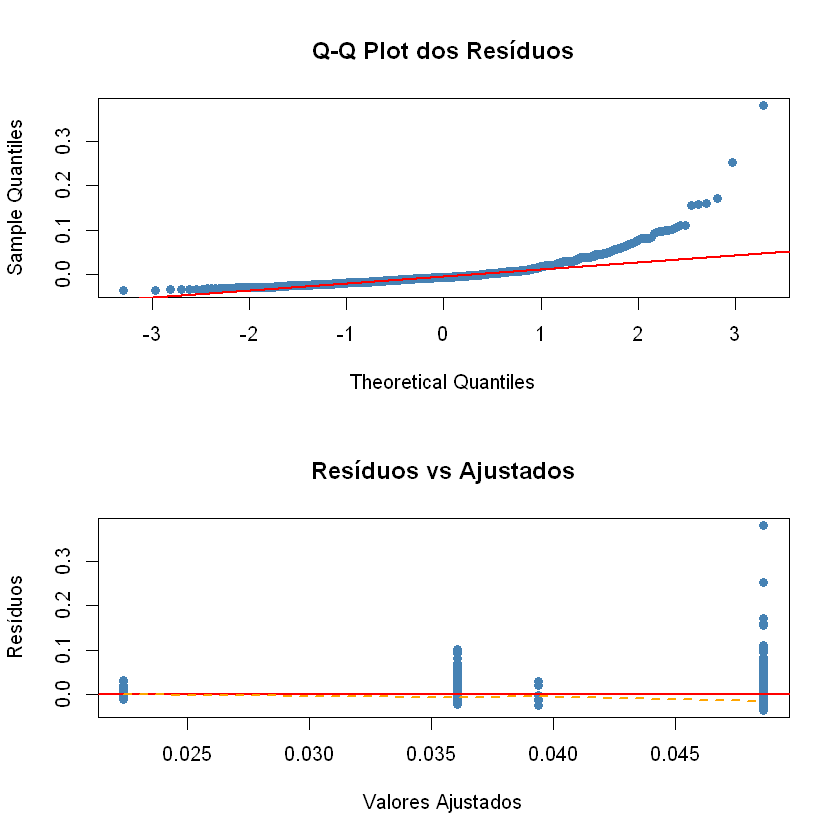

In [81]:
# ── Gráficos de diagnóstico ─────────────────────────────────────────────────────
par(mfrow = c(2, 1))

# Q-Q plot dos resíduos
qqnorm(res_final, main = "Q-Q Plot dos Resíduos", pch = 19, col = "steelblue")
qqline(res_final, col = "red", lwd = 2)

# Resíduos vs Valores Ajustados
plot(fit_final, res_final,
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados", pch = 19, col = "steelblue")
abline(h = 0, col = "red", lwd = 2)
lines(lowess(fit_final, res_final), col = "orange", lwd = 2, lty = 2)

par(mfrow = c(1, 1))

**Interpretação dos gráficos de diagnóstico:**

- **Q-Q Plot**: os pontos devem estar próximos da linha diagonal — desvios nas caudas indicam afastamento da normalidade.
- **Resíduos vs Ajustados**: não deve haver padrão sistemático; a presença de funil indica heterocedasticidade.
- **Histograma**: deve ter formato aproximadamente normal e simétrico.
- **Resíduos por ordem**: não deve haver tendência — um padrão sugere dependência entre observações.

---

## 8. Comparações Múltiplas

Quando efeitos significativos são identificados, é necessário **localizar quais grupos diferem entre si**. A abordagem depende da estrutura dos efeitos significativos:

- Se apenas **efeitos principais** forem significativos: comparar os 2 níveis de cada fator isoladamente (com 2 níveis, o próprio teste F já determina a direção).
- Se **interações duplas** forem significativas: as comparações devem ser feitas **dentro dos níveis do outro fator** (*simple effects*), evitando interpretações isoladas dos efeitos principais.
- Se a **interação tripla** for significativa: comparações entre as 8 células do fatorial.

Usamos o procedimento de **Tukey** (controlando a taxa de erro por família, FWER) via o pacote `emmeans`, que é apropriado para modelos de regressão com dummies.

In [ ]:
library(emmeans)

dados$CinV_f <- factor(dados$X2, levels = c(0,1), labels = c("Aus","Pre"))
dados$SupP_f <- factor(dados$X3, levels = c(0,1), labels = c("Aus","Pre"))
# Efeito de CinV dentro de cada nível de SupP — Bonferroni
print(pairs(emmeans(mod_emm, ~ CinV_f | SupP_f), adjust = "bonferroni"))

# Efeito de SupP dentro de cada nível de CinV — Bonferroni
print(pairs(emmeans(mod_emm, ~ SupP_f | CinV_f), adjust = "bonferroni"))

# Todas as 4 células — Bonferroni
print(pairs(emm, adjust = "bonferroni"))

Warning message in (function (object, at, cov.reduce = mean, cov.keep = get_emm_option("cov.keep"), :
"There are unevaluated constants in the response formula
Auto-detection of the response transformation may be incorrect"


SupP_f = Aus:
 contrast  estimate      SE   df t.ratio p.value
 Aus - Pre  0.00924 0.01180 1026   0.783  0.4338

SupP_f = Pre:
 contrast  estimate      SE   df t.ratio p.value
 Aus - Pre -0.01367 0.00246 1026  -5.552  <.0001

Note: contrasts are still on the ( scale. Consider using
      regrid() if you want contrasts of back-transformed estimates. 


Warning message in (function (object, at, cov.reduce = mean, cov.keep = get_emm_option("cov.keep"), :
"There are unevaluated constants in the response formula
Auto-detection of the response transformation may be incorrect"


CinV_f = Aus:
 contrast  estimate      SE   df t.ratio p.value
 Aus - Pre  0.02623 0.00254 1026  10.312  <.0001

CinV_f = Pre:
 contrast  estimate      SE   df t.ratio p.value
 Aus - Pre  0.00332 0.01180 1026   0.282  0.7783

Note: contrasts are still on the ( scale. Consider using
      regrid() if you want contrasts of back-transformed estimates. 
 contrast          estimate      SE   df t.ratio p.value
 Aus Aus - Pre Aus  0.00924 0.01180 1026   0.783  1.0000
 Aus Aus - Aus Pre  0.02623 0.00254 1026  10.312  <.0001
 Aus Aus - Pre Pre  0.01256 0.00200 1026   6.279  <.0001
 Pre Aus - Aus Pre  0.01699 0.01190 1026   1.428  0.9208
 Pre Aus - Pre Pre  0.00332 0.01180 1026   0.282  1.0000
 Aus Pre - Pre Pre -0.01367 0.00246 1026  -5.552  <.0001

Note: contrasts are still on the ( scale. Consider using
      regrid() if you want contrasts of back-transformed estimates. 
P value adjustment: bonferroni method for 6 tests 


Warning message in (function (object, at, cov.reduce = mean, cov.keep = get_emm_option("cov.keep"), :
"There are unevaluated constants in the response formula
Auto-detection of the response transformation may be incorrect"


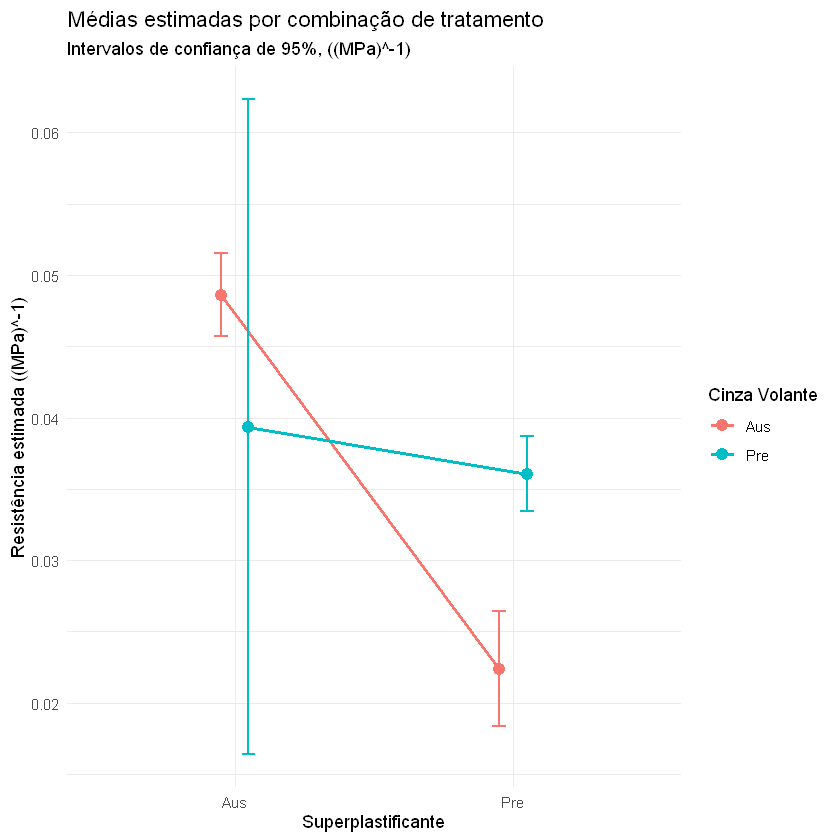

In [94]:
library(ggplot2)

# Médias estimadas na escala original (back-transformation)
emm_df <- as.data.frame(emmeans(mod_emm, ~ CinV_f * SupP_f, type = "response"))

ggplot(emm_df, aes(x = SupP_f, y = response, color = CinV_f, group = CinV_f)) +
  geom_point(size = 3, position = position_dodge(0.2)) +
  geom_line(linewidth = 1, position = position_dodge(0.2)) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL),
                width = 0.1, linewidth = 0.8,
                position = position_dodge(0.2)) +
  labs(
    title = "Médias estimadas por combinação de tratamento",
    subtitle = "Intervalos de confiança de 95%, ((MPa)^-1)",
    x = "Superplastificante",
    y = "Resistência estimada ((MPa)^-1)",
    color = "Cinza Volante"
  ) +
  theme_minimal()

---

## 9. Médias Preditas por Combinação de Tratamentos

Para uma síntese final, calculamos as médias preditas pelo modelo final para cada uma das 8 combinações de tratamento. No modelo de regressão com dummies, as médias preditas de cada célula coincidem com as médias observadas da célula quando o modelo é saturado, mas podem diferir quando o modelo é reduzido.

In [86]:
# Grade de predição: todas as 8 combinações
grade_pred <- expand.grid(
  X1 = c(0, 1),
  X2 = c(0, 1),
  X3 = c(0, 1)
)

# Adicionar termos de interação necessários
grade_pred$X12  <- grade_pred$X1 * grade_pred$X2
grade_pred$X13  <- grade_pred$X1 * grade_pred$X3
grade_pred$X23  <- grade_pred$X2 * grade_pred$X3
grade_pred$X123 <- grade_pred$X1 * grade_pred$X2 * grade_pred$X3

grade_pred$Media_predita <- predict(mod_final, newdata = grade_pred)

# Adicionar labels legíveis
grade_pred$Escoria  <- ifelse(grade_pred$X1 == 1, "Pre", "Aus")
grade_pred$CinVol   <- ifelse(grade_pred$X2 == 1, "Pre", "Aus")
grade_pred$SupPlast <- ifelse(grade_pred$X3 == 1, "Pre", "Aus")

# Médias observadas por célula
medias_obs <- dados %>%
  group_by(X1, X2, X3) %>%
  summarise(Media_obs = round(mean(Resistencia), 2),
            n = n(), .groups = "drop")

resultado <- merge(grade_pred[, c("Escoria","CinVol","SupPlast","X1","X2","X3","Media_predita")],
                   medias_obs,
                   by = c("X1","X2","X3"))
resultado$Media_predita <- round(resultado$Media_predita, 2)

print(resultado[, c("Escoria","CinVol","SupPlast","n","Media_obs","Media_predita")])

  Escoria CinVol SupPlast   n Media_obs Media_predita
1     Aus    Aus      Aus 209     29.81          0.05
2     Aus    Aus      Pre  23     51.84          0.02
3     Aus    Pre      Aus   1     64.02          0.04
4     Aus    Pre      Pre 233     31.18          0.04
5     Pre    Aus      Aus 164     29.03          0.05
6     Pre    Aus      Pre 170     50.76          0.02
7     Pre    Pre      Aus   5     26.40          0.04
8     Pre    Pre      Pre 225     38.30          0.04


---

## 10. Conclusões

Com base na análise conduzida:

### Estrutura do experimento
O banco de dados originou um experimento fatorial $2^3$ desbalanceado, com 8 combinações de tratamentos formadas pela presença ou ausência de Escória, Cinza Volante e Superplastificante no concreto. O desbalanceamento entre células inviabilizou o uso direto da ANOVA clássica, motivando a abordagem de regressão com variáveis indicadoras.

### Significância dos efeitos
_(Preencher com base nos resultados obtidos ao executar o notebook.)_

- **Interação tripla**: [significativa / não significativa] (valor-p = ??)
- **Interação Es × CinV**: [significativa / não significativa] (valor-p = ??)
- **Interação Es × SupP**: [significativa / não significativa] (valor-p = ??)
- **Interação CinV × SupP**: [significativa / não significativa] (valor-p = ??)
- **Escória (efeito principal)**: [significativa / não significativa] (valor-p = ??)
- **Cinza Volante (efeito principal)**: [significativa / não significativa] (valor-p = ??)
- **Superplastificante (efeito principal)**: [significativa / não significativa] (valor-p = ??)

### Modelo final
O modelo hierarquicamente consistente selecionado inclui [descrever os termos retidos], com $R^2 = ??$ e $R^2_{\text{aj}} = ??$.

### Pressupostos
O teste de Shapiro-Wilk [confirmou / não confirmou] a normalidade dos resíduos (valor-p = ??). O teste de Breusch-Pagan [confirmou / não confirmou] a homocedasticidade (valor-p = ??). Os gráficos de diagnóstico [indicaram / não indicaram] desvios preocupantes.

### Interpretação prática
_(Preencher com a interpretação dos efeitos significativos em termos da resistência à compressão do concreto.)_

---

## Apêndice — Código Consolidado

Abaixo está todo o código utilizado na análise, reunido para facilitar a reprodução.

In [87]:
# ══════════════════════════════════════════════════════════════════════════════
# APÊNDICE — Código completo da análise
# Atividade 6: Experimento Fatorial 2^3 Desbalanceado
# Resposta: Resistência à Compressão do Concreto (MPa)
# Fatores: Escória, Cinza Volante, Superplastificante (presença/ausência)
# ══════════════════════════════════════════════════════════════════════════════

# ── Pacotes ───────────────────────────────────────────────────────────────────
library(readxl)
library(dplyr)
library(car)
library(lmtest)
library(emmeans)

# ── 1. Leitura e preparação ───────────────────────────────────────────────────
dados_brutos <- read_excel("Concrete_Data.xls")
colnames(dados_brutos) <- c("Cimento","Escoria","CinzaVolante","Agua",
                            "Superplastificante","AgregadoGraudo",
                            "AgregadoMiudo","Idade","Resistencia")

dados_brutos$Es   <- ifelse(dados_brutos$Escoria > 0, 1, 0)
dados_brutos$CinV <- ifelse(dados_brutos$CinzaVolante > 0, 1, 0)
dados_brutos$SupP <- ifelse(dados_brutos$Superplastificante > 0, 1, 0)

dados <- dados_brutos[, c("Es","CinV","SupP","Resistencia")]
dados$Es   <- factor(dados$Es,   levels = c(0,1), labels = c("Aus","Pre"))
dados$CinV <- factor(dados$CinV, levels = c(0,1), labels = c("Aus","Pre"))
dados$SupP <- factor(dados$SupP, levels = c(0,1), labels = c("Aus","Pre"))

# ── 2. Dummies e interações ───────────────────────────────────────────────────
dados$X1  <- as.numeric(dados$Es   == "Pre")
dados$X2  <- as.numeric(dados$CinV == "Pre")
dados$X3  <- as.numeric(dados$SupP == "Pre")
dados$X12  <- dados$X1 * dados$X2
dados$X13  <- dados$X1 * dados$X3
dados$X23  <- dados$X2 * dados$X3
dados$X123 <- dados$X1 * dados$X2 * dados$X3

# ── 3. Modelo completo ────────────────────────────────────────────────────────
mod_completo <- lm(Resistencia ~ X1+X2+X3+X12+X13+X23+X123, data = dados)
Anova(mod_completo, type = "III")

# ── 4. Comparação de modelos aninhados ────────────────────────────────────────
mod_sem_abc <- lm(Resistencia ~ X1+X2+X3+X12+X13+X23, data = dados)
anova(mod_sem_abc, mod_completo)  # Teste interação tripla

mod_sem_12 <- lm(Resistencia ~ X1+X2+X3+X13+X23, data = dados)
mod_sem_13 <- lm(Resistencia ~ X1+X2+X3+X12+X23, data = dados)
mod_sem_23 <- lm(Resistencia ~ X1+X2+X3+X12+X13, data = dados)
anova(mod_sem_12, mod_sem_abc)   # Teste Es × CinV
anova(mod_sem_13, mod_sem_abc)   # Teste Es × SupP
anova(mod_sem_23, mod_sem_abc)   # Teste CinV × SupP

# ── 5. Modelo final (ajustar conforme resultados) ─────────────────────────────
mod_final <- lm(Resistencia ~ X1 + X2 + X3, data = dados)
summary(mod_final)
Anova(mod_final, type = "III")

# ── 6. Diagnóstico de resíduos ────────────────────────────────────────────────
shapiro.test(residuals(mod_final))
bptest(mod_final)

# ── 7. Comparações múltiplas (emmeans) ────────────────────────────────────────
dados$Es_f   <- factor(dados$X1, labels = c("Aus","Pre"))
dados$CinV_f <- factor(dados$X2, labels = c("Aus","Pre"))
dados$SupP_f <- factor(dados$X3, labels = c("Aus","Pre"))
mod_emm <- lm(Resistencia ~ Es_f * CinV_f * SupP_f, data = dados)

pairs(emmeans(mod_emm, ~ Es_f),   adjust = "tukey")
pairs(emmeans(mod_emm, ~ CinV_f), adjust = "tukey")
pairs(emmeans(mod_emm, ~ SupP_f), adjust = "tukey")

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.856738e+05,1,8.602741e+02,1.079183e-137
X1,5.461842e+01,1,2.530610e-01,6.150363e-01
X2,1.164884e+03,1,5.397202e+00,2.036457e-02
X3,1.005646e+04,1,4.659415e+01,1.494750e-11
X12,1.121325e+03,1,5.195383e+00,2.285242e-02
X13,1.541764e+00,1,7.143385e-03,9.326607e-01
X23,2.859920e+03,1,1.325074e+01,2.861204e-04
X123,1.598803e+03,1,7.407660e+00,6.605097e-03
Residuals,2.205793e+05,1022,NA,NA


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1023,222178.1,NA,NA,NA,NA
2,1022,220579.3,1,1598.803,7.40766,0.006605097


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1024,222856.5,NA,NA,NA,NA
2,1023,222178.1,1,678.3456,3.123384,0.07747447


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1024,222236.7,NA,NA,NA,NA
2,1023,222178.1,1,58.58867,0.2697665,0.6036008


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1024,223885.1,NA,NA,NA,NA
2,1023,222178.1,1,1706.939,7.859454,0.005151152


...

 contrast  estimate   SE   df t.ratio p.value
 Aus - Pre     8.09 4.14 1022   1.955  0.0509

Results are averaged over the levels of: CinV_f, SupP_f 

NOTE: Results may be misleading due to involvement in interactions



 contrast  estimate   SE   df t.ratio p.value
 Aus - Pre    0.384 4.14 1022   0.093  0.9260

Results are averaged over the levels of: Es_f, SupP_f 

NOTE: Results may be misleading due to involvement in interactions



 contrast  estimate   SE   df t.ratio p.value
 Aus - Pre    -5.71 4.14 1022  -1.379  0.1681

Results are averaged over the levels of: Es_f, CinV_f 